# Infinite Potential Wells

In [6]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib notebook
from tqdm import tqdm
from cycler import cycler

from scipy.special import jv, spherical_jn, jn_zeros, sph_harm
import scipy.optimize
from scipy.integrate import simps

# 1D Infinite Square Well

## 2D Infinite Square Well 

<IPython.core.display.Javascript object>


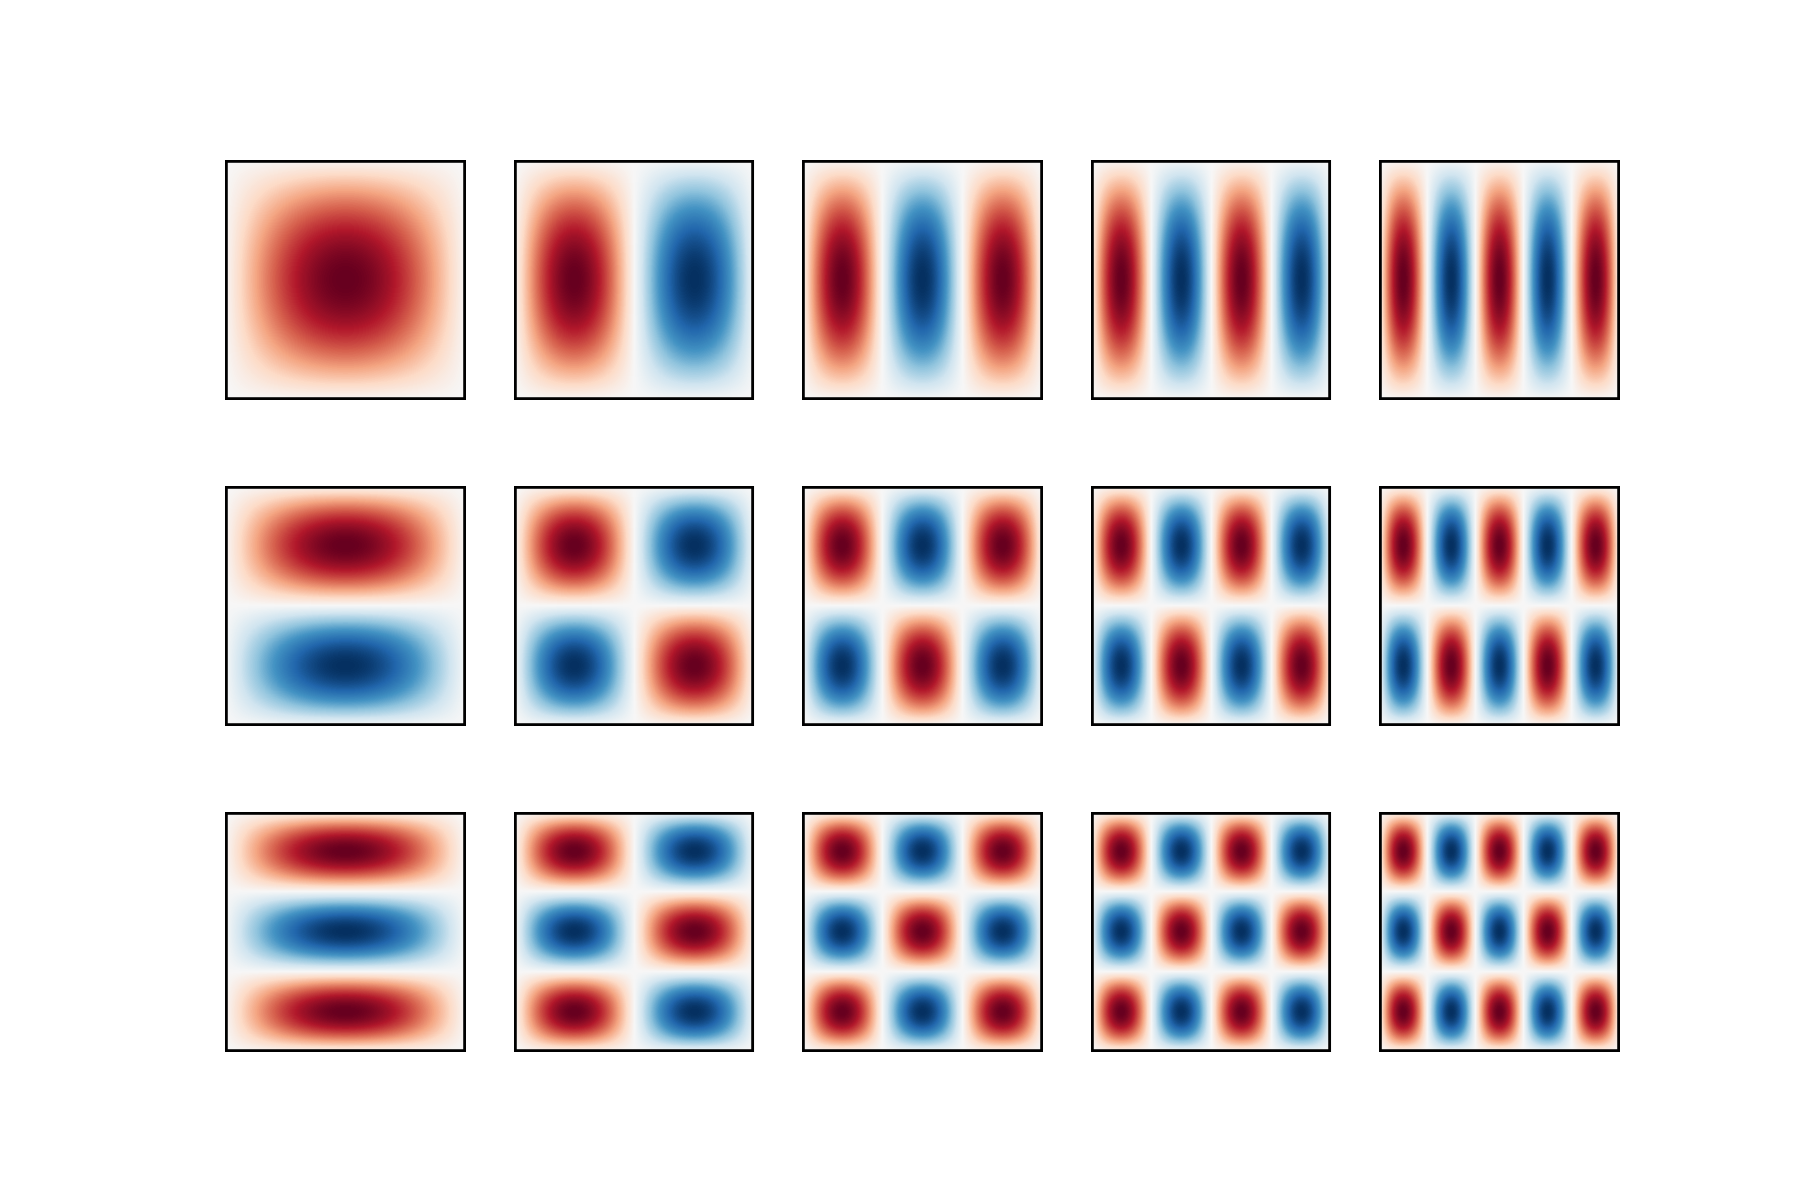

In [4]:
# 2D Square Well Wavefunctions

N= 500
L=1
x, y = np.linspace(0, L, N), np.linspace(0, L, N)
X, Y = np.meshgrid(x, y)

mvals = np.arange(1, 6)
nvals = np.arange(1, 4)
fig, axs = plt.subplots(len(nvals), len(mvals), figsize = (9,6))

def plot_wavefunction(axs, m, n):
    psi = np.sin(np.pi*m*X)*np.sin(np.pi*n*Y)

    pmax = np.amax(psi)
    pmin = np.amin(psi)
    pext = max(pmax, -pmin)

    axs.imshow(psi, vmin=-pext, vmax = pext, cmap='RdBu_r', extent =[0, 1, 0, 1])
    
    axs.plot([0, 0], [0,1], 'k', lw=2)
    axs.plot([1, 1], [0,1], 'k', lw=2)
    axs.plot([0, 1], [0,0], 'k', lw=2)
    axs.plot([0, 1], [1,1], 'k', lw=2)
    
    axs.set_axis_off()
    

for i, m in enumerate(mvals):
    for j, n in enumerate(nvals):
        plot_wavefunction(axs[j, i], m, n)

#for i, n in enumerate(nvals):
#    axs[i, 0].set_ylabel('$n=$ '+str(int(n)), rotation=0)
    
#for j, m in enumerate(mvals):
#    axs[0, j].set_title('$m=$ '+str(int(m)))  
    
#plt.tight_layout()
    
plt.show()

# 2D Infinite Circular Well

<IPython.core.display.Javascript object>


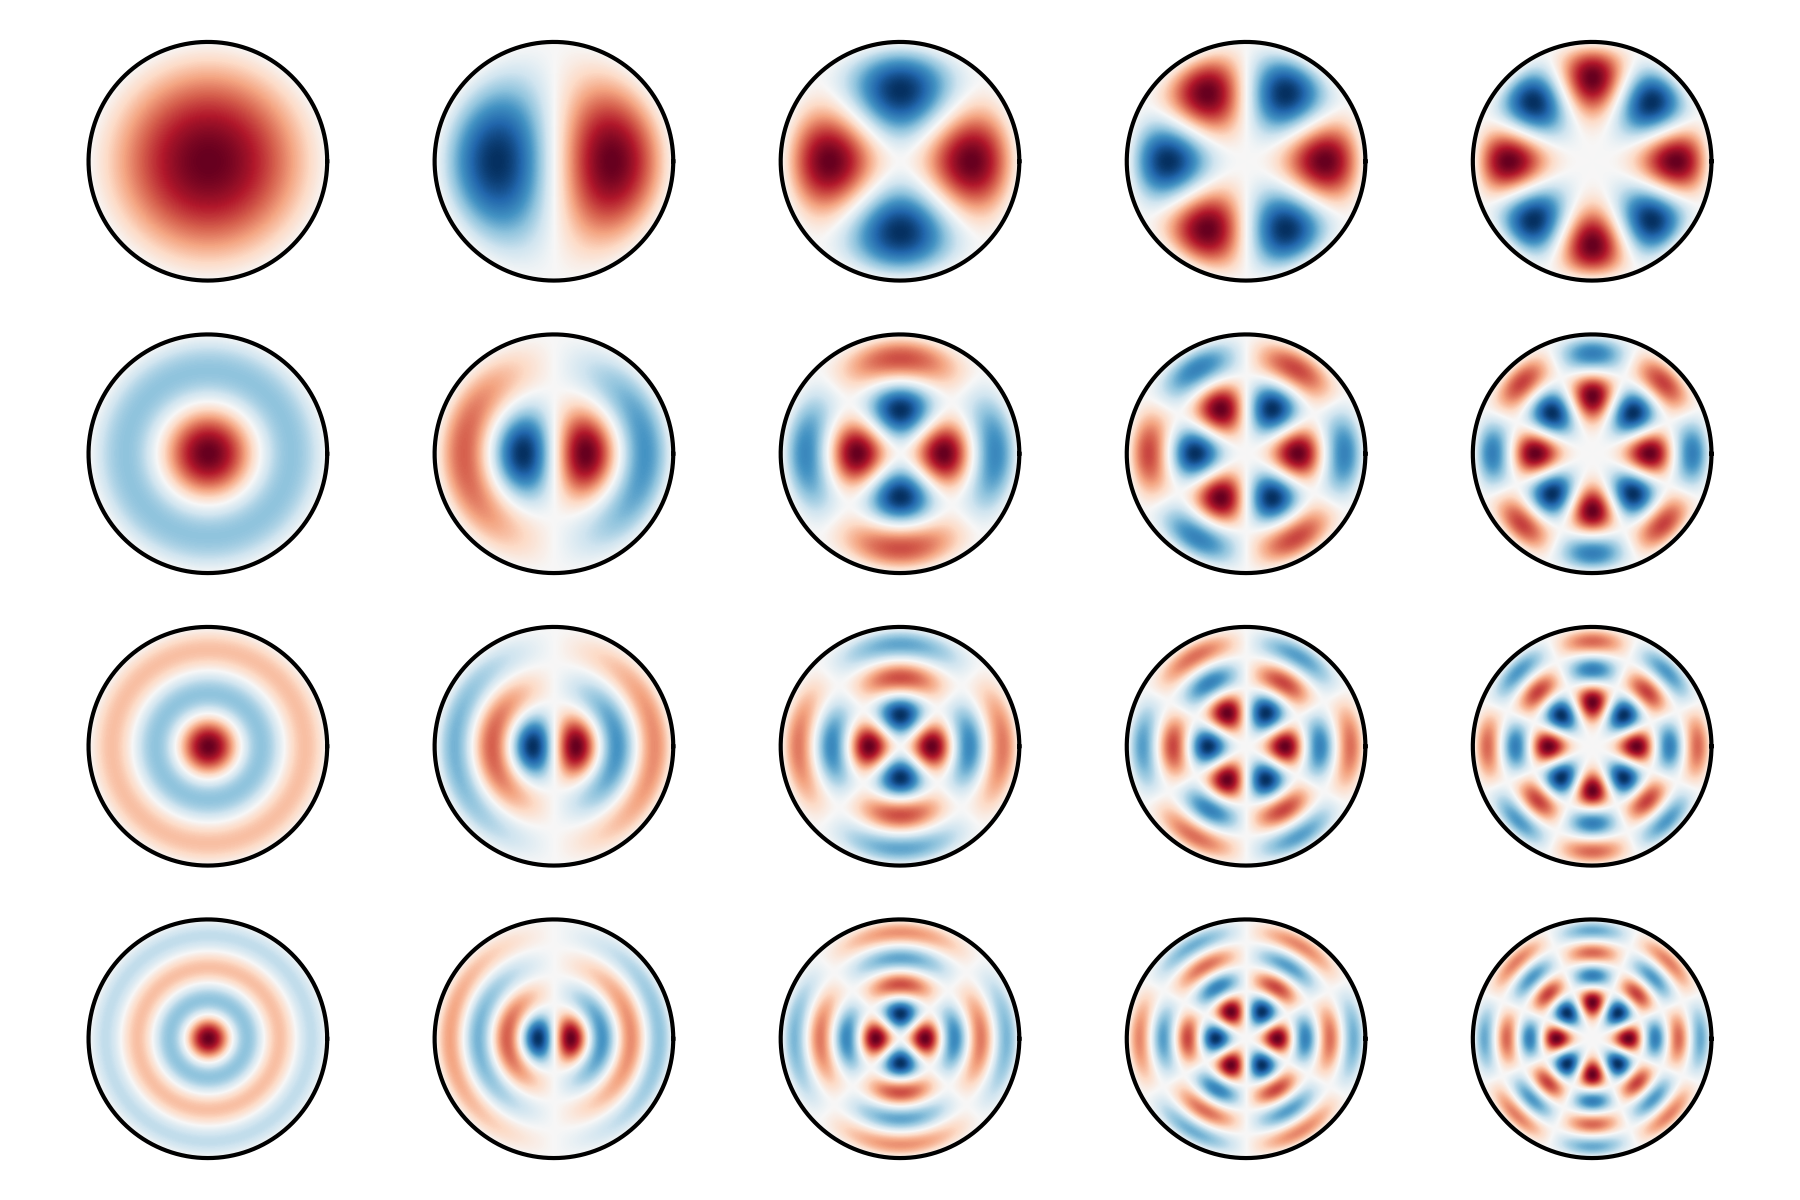

In [12]:
# 2D Circular Well Wavefunctions

N= 500
radius=1
x, y = np.linspace(-radius, radius, N), np.linspace(-radius, radius, N)
X, Y = np.meshgrid(x, y)

R = np.sqrt(X**2 + Y**2)
T = np.arctan2(Y, X)

t = np.linspace(0, 2*np.pi, 1000) # For parameterizing outline

OOB_mask = R > radius
IB_mask = R < radius

mvals = np.arange(5)
nvals = np.arange(4)
fig, axs = plt.subplots(4, 5, figsize = (9,6))

def plot_2D_wavefunction(axs, m, n):
    zeros = jn_zeros(m, n+1) # Zeros of Bessel function
    psi = jv(m, R*zeros[n])*np.cos(m*T) # Wavefunction

    pmax = np.amax(psi[IB_mask])
    pmin = np.amin(psi[IB_mask])
    pext = max(pmax, -pmin)
    psi[OOB_mask] = float('nan')
    axs.imshow(psi, vmin=-pext, vmax = pext, cmap='RdBu_r', extent =[-1, 1, -1, 1])

    axs.plot(np.cos(t), np.sin(t), 'k')
    axs.set_xlim(-1.1, 1.1)
    axs.set_ylim(-1.1, 1.1)
    
    axs.set_axis_off()
    

for i, m in enumerate(mvals):
    for j, n in enumerate(nvals):
        plot_2D_wavefunction(axs[j, i], m, n)
        
plt.tight_layout()
    
plt.show()

# 3D Infinite Spherical Well

The radial problem in 3D is really not all that different - we just have to use spherical Bessel functions instead of regular Bessel functions. However, scipy does not provide a built-in function for the zeros of the spherical Bessels, so we need to whip up a quick and dirty one. 

In [ ]:
def sphericalBesselBrent(x, n):
    return spherical_jn(n, x)

def spherical_jn_zeros(n, num_zeros):

    """
    Determines the first few zeros of the spherical Bessel function of the first kind.
    Useful for plotting radial wavefunctions for the infinite spherical well. 
    
    """
    zeros=[]
    
    # Updating bounds
    left = 1
    right= left+np.pi

    while len(zeros)<num_zeros:
        try:
            x0 = scipy.optimize.brentq(sphericalBesselBrent, left, right, args = (n))
            zeros.append(x0)
            left =x0+0.1
            right=left+np.pi
        except:
            right+=np.pi
    
    return zeros

## Spherical Well Wavefunctions

<IPython.core.display.Javascript object>


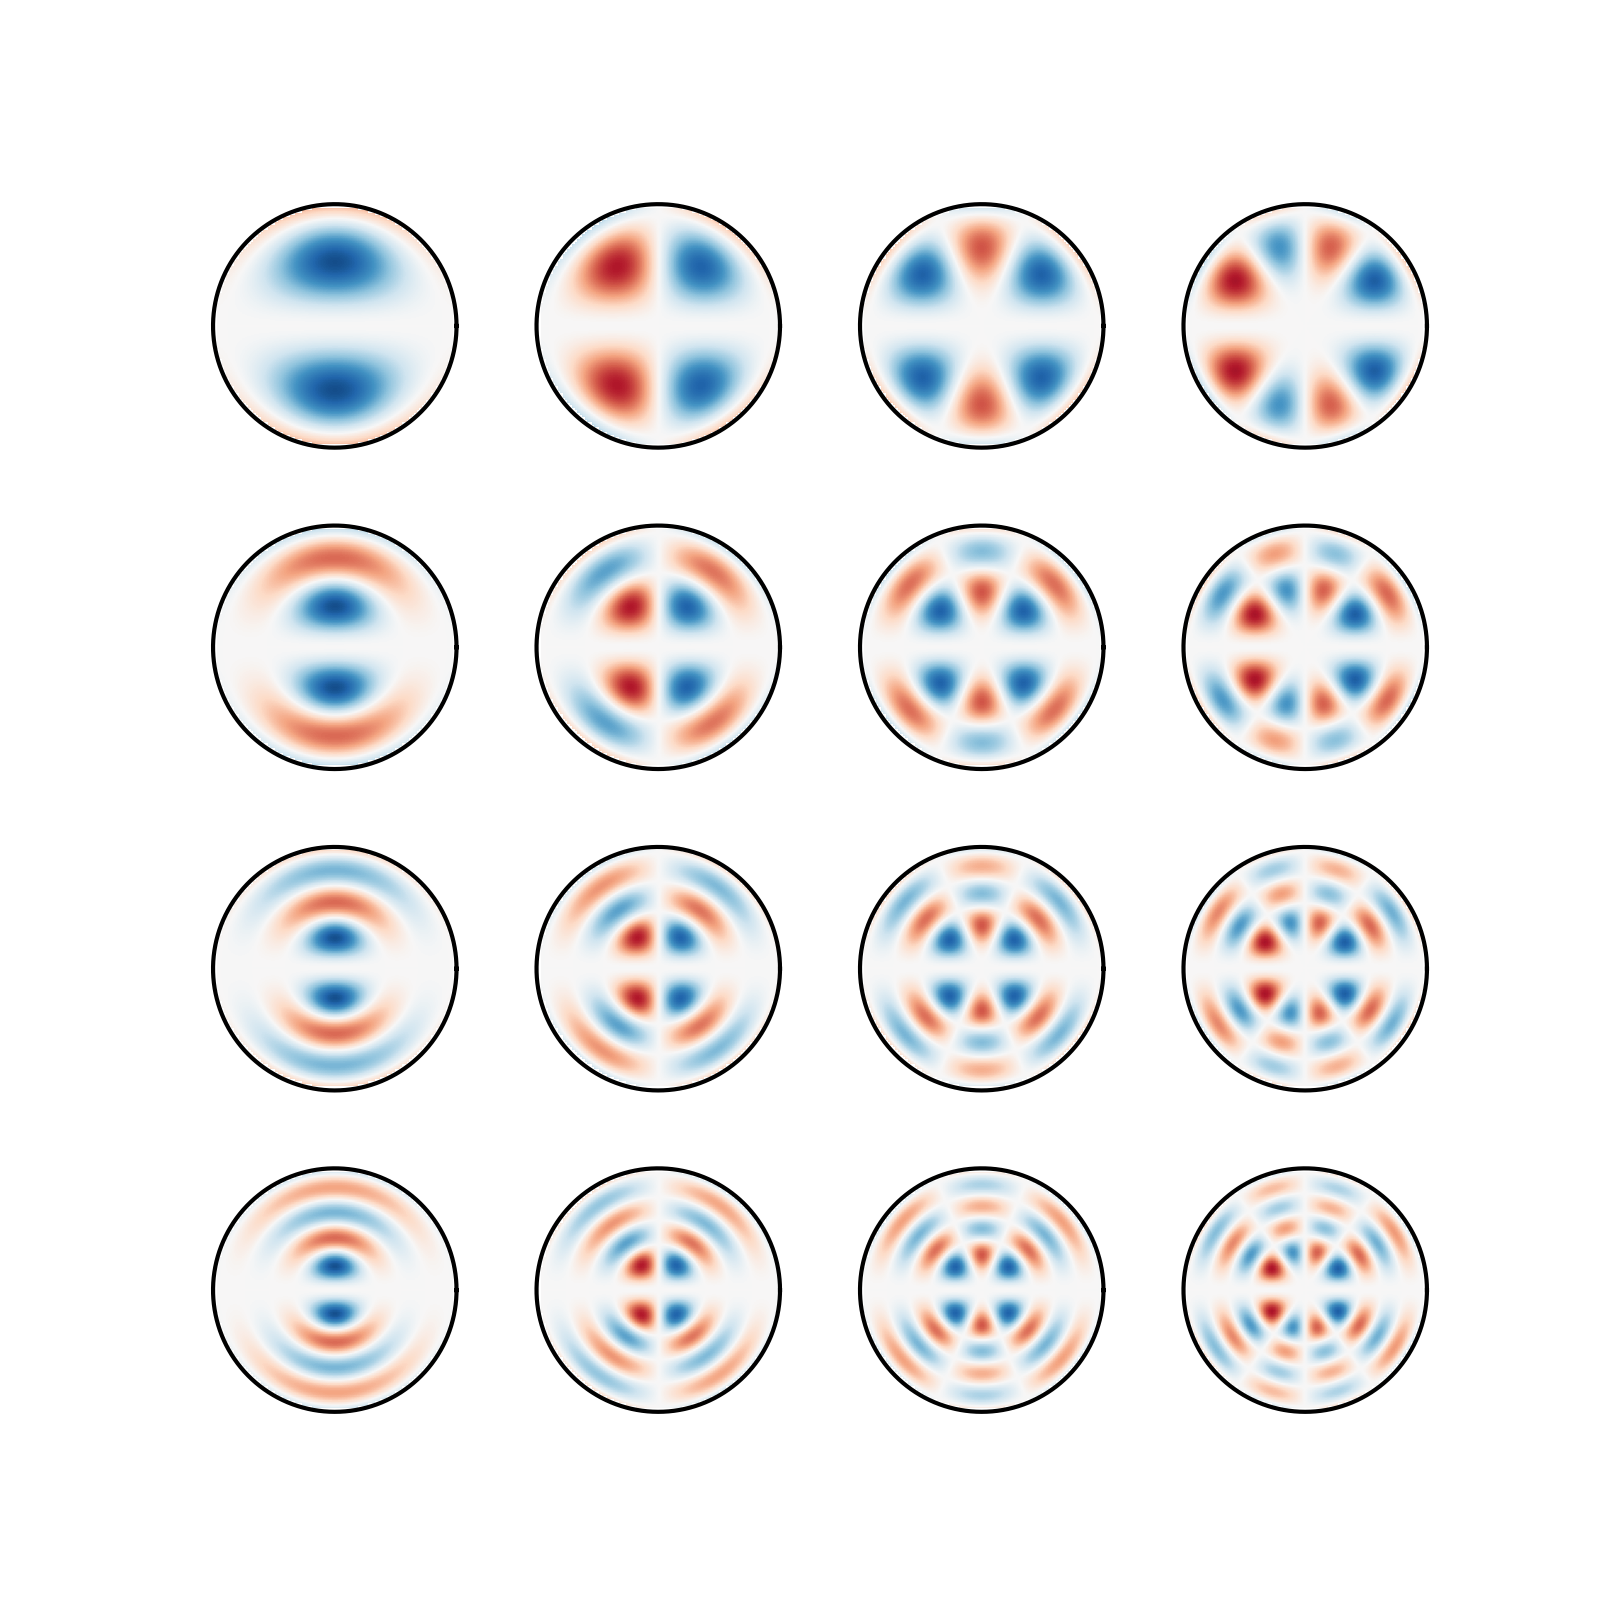

In [15]:
# 3D Spherical Well Wavefunctions
from scipy.special import sph_harm

N= 100
radius=1
x =np.linspace(-radius, radius, N)
y =np.linspace(-radius, radius, N)
z =np.linspace(-radius, radius, N)

X, Y, Z = np.meshgrid(x, y, z)

R = np.sqrt(X**2 + Y**2 +Z**2)
T = np.arccos(Z/R)
P = np.arctan2(Y, X)

t = np.linspace(0, 2*np.pi, 1000) # For parameterizing outline

OOB_mask = R > radius
IB_mask = R < radius

lvals = np.arange(2, 6)
nvals = np.arange(0, 4)
m=2
fig, axs = plt.subplots(len(nvals), len(lvals), figsize = (8,8))


def plot_3D_wavefunction(axs, l, m, n):
    zeros = spherical_jn_zeros(l, n+1) # Zeros of Bessel function
    
    Y = sph_harm(m, l, P, T)

    # Linear combination of Y_l,m and Y_l,-m to create the real form.
    if m < 0:
        Y = np.sqrt(2) * (-1)**m * Y.imag
    elif m > 0:
        Y = np.sqrt(2) * (-1)**m * Y.real
    
    psi = jv(l, R*zeros[n])*np.real(Y) # Wavefunction
    psi_slice = psi[:, N//2, :]
    
    pmax = np.amax(psi_slice)
    pmin = np.amin(psi_slice)
    pext = max(pmax, -pmin)
    psi[OOB_mask] = float('nan')
    
    axs.imshow(psi_slice, vmin=-0.3, vmax = 0.3, cmap='RdBu_r', extent =[-1, 1, -1, 1])

    axs.plot(np.cos(t), np.sin(t), 'k')
    axs.set_xlim(-1.1, 1.1)
    axs.set_ylim(-1.1, 1.1)
    
    axs.set_axis_off()
    

for i, l in enumerate(lvals):
    for j, n in enumerate(nvals):
        plot_3D_wavefunction(axs[j, i], l, m, n)
    
plt.show()

# Scratch

## Radial Function Comparison

<IPython.core.display.Javascript object>


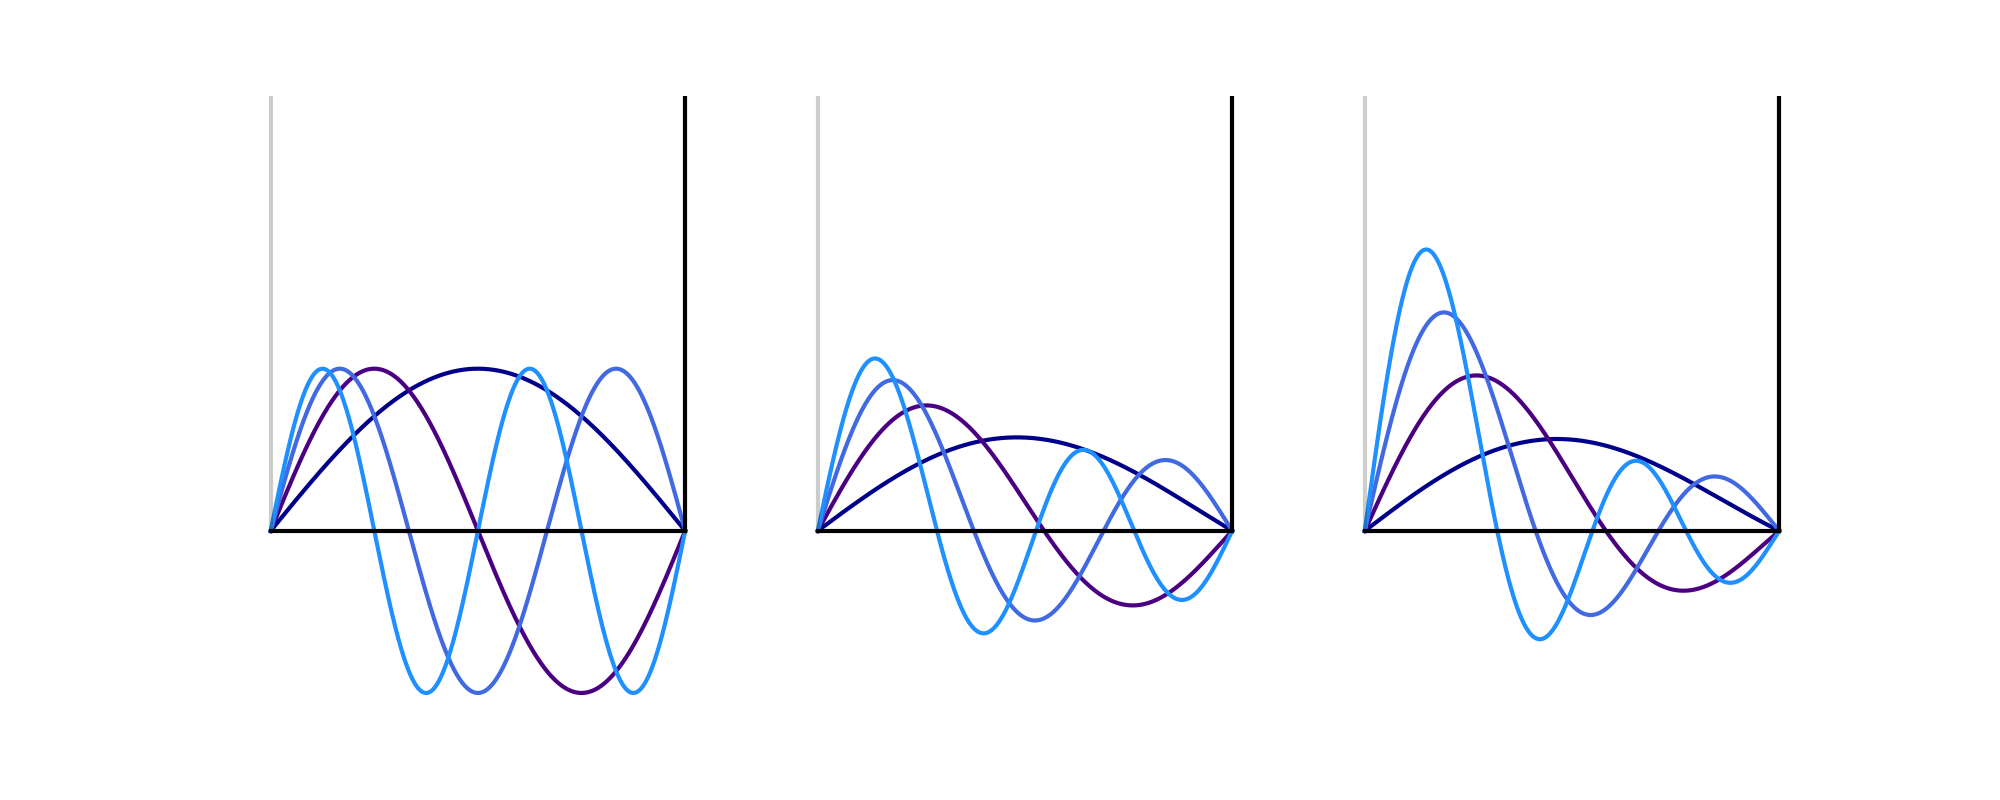

In [11]:
fig, axs = plt.subplots(1, 3, figsize = (10,4))

#Plot cycle
colors = ['darkblue', 'indigo', 'royalblue', 'dodgerblue']
custom_cycler = (cycler(color=colors) +
                 cycler(lw=[1.5 for c in colors]))

for k in range(3):
    axs[k].set_prop_cycle(custom_cycler)

x = np.linspace(0, 1, 1000)

num_zeros = 4 # Number of solutions to show

ymax = 0.12
ymin = -0.05

for k in range(1, num_zeros+1):
    y = np.sin(np.pi*k*x)
    y = y/np.sqrt(simps(y**2))
    axs[0].plot(x, y)

m = 1 # Order of the Bessel function
zeros = jn_zeros(m, num_zeros)
for i, zi in enumerate(zeros):
    y = jv(m, x*zi)
    y = y/np.sqrt(simps(x*y**2))
    axs[1].plot(x, y/np.sqrt(2*np.pi))

l = 1 # Order of the spherical Bessel function
zeros = spherical_jn_zeros(l, num_zeros)
for i, zi in enumerate(zeros):
    y=spherical_jn(l, x*zi)
    y = y/np.sqrt(simps(x**2 *y**2))
    axs[2].plot(x, y/np.sqrt(4*np.pi))
    
for k in range(3):
    axs[k].plot([0, 1], [0,0], 'k')
    axs[k].plot([0, 0], [0,ymax], 'k', alpha = 0.2)
    axs[k].plot([1, 1], [0,ymax], 'k')
    axs[k].set_ylim(ymin, ymax)
    axs[k].set_axis_off()

plt.show()